# Metric Validation

This notebook evaluates whether the three operational metrics defined in Notebook 2 are
trustworthy enough to guide decisions about the HPC cluster.

The metrics under evaluation are:

| Metric | Role |
|--------|------|
| Weekly P95 Turnaround Time | North Star |
| Weekly Failure / Non-Completion Rate | Guardrail 1 |
| Weekly Median GPU SM Utilization | Guardrail 2 |

The validation follows a structured seven-step framework:

1. **Missingness** — is the metric computable across the full population?
2. **Segmentation bias** — does the metric behave differently across workload segments?
3. **Stability** — is week-to-week variation within a tolerable range?
4. **Drift** — has the metric changed systematically between the first and second half of the year?
5. **Reliability** — how wide are the confidence intervals on tail estimates?
6. **Sensitivity** — does the metric respond to meaningful changes in workload pressure?
7. **CUPED** — can variance be reduced using pre-period information?

Each step produces a diagnostic table, statistical test, or chart. Each section concludes with
a short interpretation of what the finding means for metric governance.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as stats
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Processed dir:", PROCESSED_DIR.resolve())

Processed dir: /Users/newuser/Desktop/Victoria/Projects_2025/metric-validation-playbook/data/processed


## Load Processed Datasets

All inputs were produced and saved by Notebook 2.  
Loading parquet files for job-level tables and CSV files for weekly aggregates.

In [2]:
# Job-level tables
job_ns      = pd.read_parquet(PROCESSED_DIR / "job_level_northstar_inputs.parquet")
job_fail    = pd.read_parquet(PROCESSED_DIR / "job_level_failure_inputs.parquet")
job_joined  = pd.read_parquet(PROCESSED_DIR / "job_level_metrics_joined.parquet")

# Weekly aggregate tables
weekly_ns   = pd.read_csv(PROCESSED_DIR / "weekly_northstar_metrics.csv")
weekly_fail = pd.read_csv(PROCESSED_DIR / "weekly_failure_metrics.csv")
weekly_gpu  = pd.read_csv(PROCESSED_DIR / "weekly_gpu_metrics.csv")
weekly      = pd.read_csv(PROCESSED_DIR / "weekly_metrics_combined.csv")

# GPU-observed job subset
gpu_jobs = job_joined[job_joined["gpu_observed"]].copy()

print("job_ns:     ", job_ns.shape)
print("job_fail:   ", job_fail.shape)
print("job_joined: ", job_joined.shape)
print("weekly_ns:  ", weekly_ns.shape)
print("weekly_fail:", weekly_fail.shape)
print("weekly_gpu: ", weekly_gpu.shape)
print("weekly:     ", weekly.shape)

job_ns:      (217638, 10)
job_fail:    (287069, 34)
job_joined:  (217638, 45)
weekly_ns:   (53, 7)
weekly_fail: (53, 4)
weekly_gpu:  (18, 5)
weekly:      (53, 14)


### 1. Missingness


A metric built on incomplete data can be systematically misleading even before any
analysis begins. Missingness must be understood at three levels:

- **Population coverage** — what share of jobs is the metric computable on?
- **Temporal coverage** — does missingness vary across weeks (could distort trend analysis)?
- **Segment coverage** — is missingness concentrated in a particular partition or job type?

#### Metrics in scope

| Metric | Population | Expected coverage |
|--------|------------|-------------------|
| P95 Turnaround | Executed jobs (valid submit/start/end) | ~75.8% of canonical jobs |
| Failure Rate | All canonical jobs with valid submit | ~100% |
| GPU Utilization | Executed jobs with DCGM telemetry | ~34.4% of executed jobs |

In [ ]:
# Top-level population coverage 

n_canonical   = len(pd.read_parquet(PROCESSED_DIR / "job_level_failure_inputs.parquet")
                    .pipe(lambda d: d))          # full canonical with valid submit
n_executed    = len(job_ns)
n_gpu_obs     = len(gpu_jobs)

n_canonical = len(job_fail)

coverage = pd.DataFrame({
    "Metric"         : ["P95 Turnaround (North Star)", "Failure Rate (Guardrail 1)", "GPU Utilization (Guardrail 2)"],
    "Population"     : ["Executed jobs",               "All jobs w/ valid submit",   "GPU-observed executed jobs"],
    "N"              : [n_executed, n_canonical, n_gpu_obs],
    "Share of canonical": [n_executed / n_canonical, 1.0, n_gpu_obs / n_canonical]
})

print("=== Population Coverage ===")
display(coverage)

=== Population Coverage ===


,Metric,Population,N,Share of canonical
0,P95 Turnaround (North Star),Executed jobs,217638,0.758
1,Failure Rate (Guardrail 1),All jobs w/ valid submit,287069,1.000
2,GPU Utilization (Guardrail 2),GPU-observed executed jobs,74838,0.261


In [ ]:
#  Weekly coverage: how many weeks have enough data?

MIN_JOBS_NS  = 50    # minimum jobs per week for a stable P95 estimate
MIN_JOBS_GPU = 10    # GPU-observed jobs are sparser

ns_coverage  = (weekly_ns["jobs"]     >= MIN_JOBS_NS ).sum()
gpu_coverage = (weekly_gpu["gpu_jobs"] >= MIN_JOBS_GPU).sum()
total_weeks  = weekly_ns["t_rel_week"].nunique()

print(f"Total weeks in dataset: {total_weeks}")
print(f"Weeks with >= {MIN_JOBS_NS} executed jobs (North Star usable):  {ns_coverage} / {total_weeks}")
print(f"Weeks with >= {MIN_JOBS_GPU} GPU-observed jobs (GPU util usable): {gpu_coverage} / {total_weeks}")


thin_weeks_ns = weekly_ns[weekly_ns["jobs"] < MIN_JOBS_NS][["t_rel_week","jobs"]]
if len(thin_weeks_ns):
    print("\nThin weeks for North Star:")
    display(thin_weeks_ns)

Total weeks in dataset: 53
Weeks with >= 50 executed jobs (North Star usable):  53 / 53
Weeks with >= 10 GPU-observed jobs (GPU util usable): 18 / 53


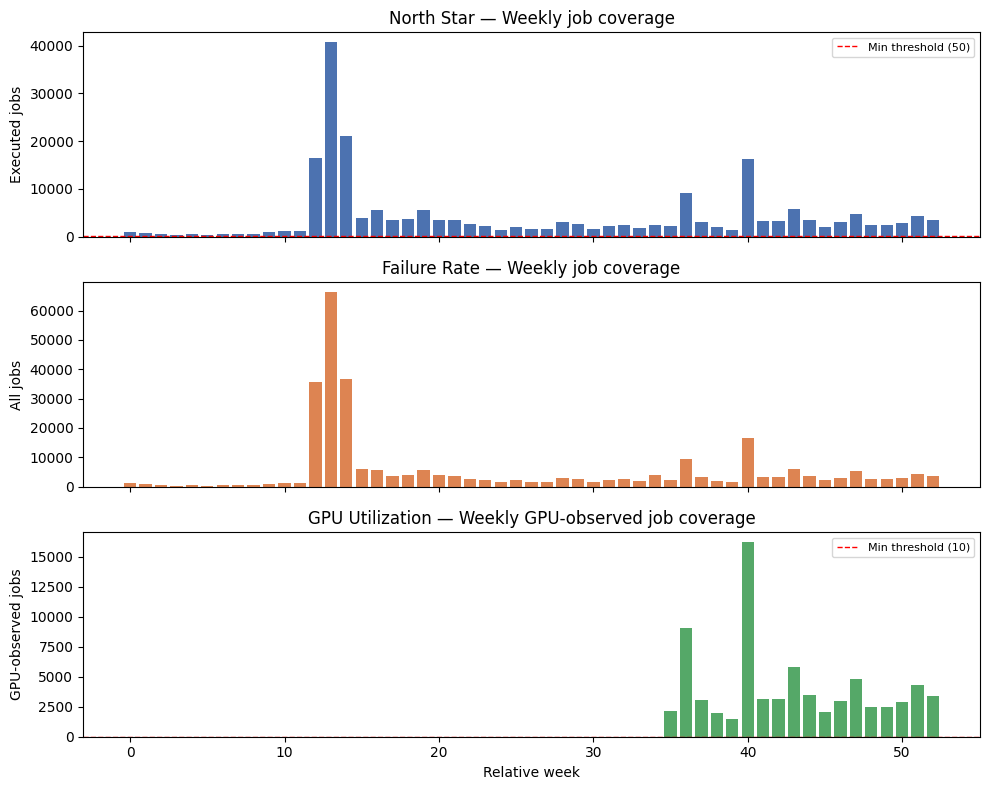

In [5]:
#  Temporal coverage: weekly job counts for all three metrics 

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].bar(weekly_ns["t_rel_week"],   weekly_ns["jobs"],      color="#4C72B0", width=0.8)
axes[0].axhline(MIN_JOBS_NS, color="red", linestyle="--", linewidth=1, label=f"Min threshold ({MIN_JOBS_NS})")
axes[0].set_ylabel("Executed jobs")
axes[0].set_title("North Star — Weekly job coverage")
axes[0].legend(fontsize=8)

axes[1].bar(weekly_fail["t_rel_week"], weekly_fail["jobs"],     color="#DD8452", width=0.8)
axes[1].set_ylabel("All jobs")
axes[1].set_title("Failure Rate — Weekly job coverage")

axes[2].bar(weekly_gpu["t_rel_week"],  weekly_gpu["gpu_jobs"],  color="#55A868", width=0.8)
axes[2].axhline(MIN_JOBS_GPU, color="red", linestyle="--", linewidth=1, label=f"Min threshold ({MIN_JOBS_GPU})")
axes[2].set_ylabel("GPU-observed jobs")
axes[2].set_xlabel("Relative week")
axes[2].set_title("GPU Utilization — Weekly GPU-observed job coverage")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

=== GPU Telemetry Coverage by Partition ===


,partition,executed_jobs,gpu_observed_jobs,gpu_coverage
0,test,5,4,0.800
1,normal,106235,74118,0.698
2,gaia,9844,716,0.073
3,gpu,101554,0,0.000


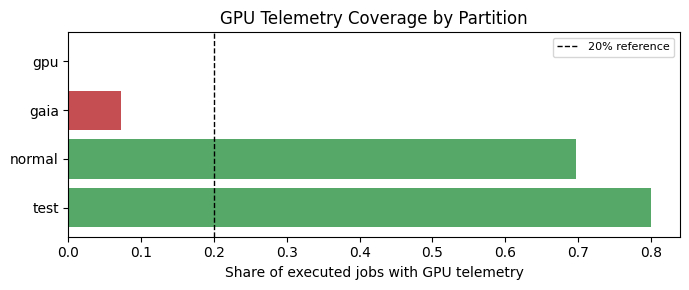

In [6]:
# Segment-level missingness: GPU telemetry by partition 

gpu_by_partition = (
    job_joined
    .groupby("partition")["gpu_observed"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "executed_jobs", "sum": "gpu_observed_jobs", "mean": "gpu_coverage"})
    .sort_values("gpu_coverage", ascending=False)
    .reset_index()
)

print("=== GPU Telemetry Coverage by Partition ===")
display(gpu_by_partition)

# Visualise
fig, ax = plt.subplots(figsize=(7, 3))
colors = ["#55A868" if v > 0.2 else "#C44E52" for v in gpu_by_partition["gpu_coverage"]]
ax.barh(gpu_by_partition["partition"], gpu_by_partition["gpu_coverage"], color=colors)
ax.set_xlabel("Share of executed jobs with GPU telemetry")
ax.set_title("GPU Telemetry Coverage by Partition")
ax.axvline(0.2, color="black", linestyle="--", linewidth=1, label="20% reference")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Interpretation

The North Star and Failure Rate metrics have solid population coverage (75.8% and 100% respectively), with no weekly gaps across the full 53-week timeline. The GPU Utilization guardrail is the critical problem: only 18 of 53 weeks are usable, and the gpu partition — where telemetry is most expected — has 0% coverage, meaning the metric actually describes normal-partition GPU jobs. It cannot be used as a year-round weekly metric and must be treated as a conditional snapshot.

### 2. Segmentation Bias


**Why this step matters**

A global metric can look stable and healthy while hiding large differences across subgroups.
If the workload mix shifts over time — for example, more GPU jobs replacing CPU jobs —
the global metric will change even if within-segment performance is unchanged. This is
a form of **Simpson's Paradox** and is a common source of misleading metric trends.

We check segmentation across two dimensions that were identified as important in EDA:
- **Partition** (`normal`, `gpu`, `gaia`)
- **CPU bucket** (`1`, `2-4`, `5-16`, `17-64`, `65+`)

=== P95 Turnaround by Partition (seconds) ===


,partition,jobs,p50,p95,p99
2,normal,106235,"2,284.000","93,242.800","345,624.000"
0,gaia,9844,795.500,"71,348.450","189,502.190"
1,gpu,101554,232.000,"14,429.000","100,517.030"
3,test,5,3.000,"1,076.200","1,178.440"


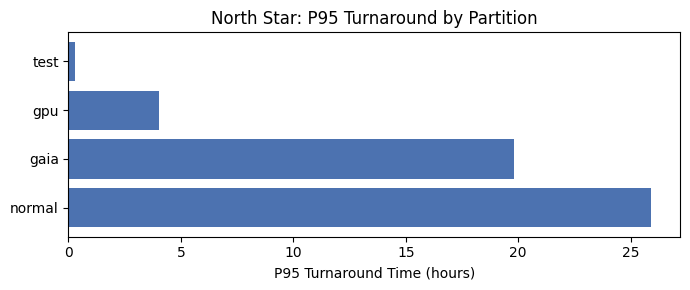

In [7]:
# North Star: P95 turnaround by partition

ns_by_partition = (
    job_ns
    .groupby("partition")["turnaround_s"]
    .agg(
        jobs="count",
        p50=lambda x: x.quantile(0.50),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99)
    )
    .reset_index()
    .sort_values("p95", ascending=False)
)

print("=== P95 Turnaround by Partition (seconds) ===")
display(ns_by_partition)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(ns_by_partition["partition"], ns_by_partition["p95"] / 3600, color="#4C72B0")
ax.set_xlabel("P95 Turnaround Time (hours)")
ax.set_title("North Star: P95 Turnaround by Partition")
plt.tight_layout()
plt.show()

=== P95 Turnaround by CPU Bucket (seconds) ===


,cpu_bucket,jobs,p50,p95,p99
0,1,125707,382.000,"15,322.500","145,356.460"
1,2-4,18618,"5,325.000","80,091.900","177,755.320"
2,5-16,21047,"2,528.000","119,662.000","511,146.240"
3,17-64,46521,"1,648.000","118,775.000","345,622.000"
4,65+,5745,291.000,"55,475.200","219,693.000"


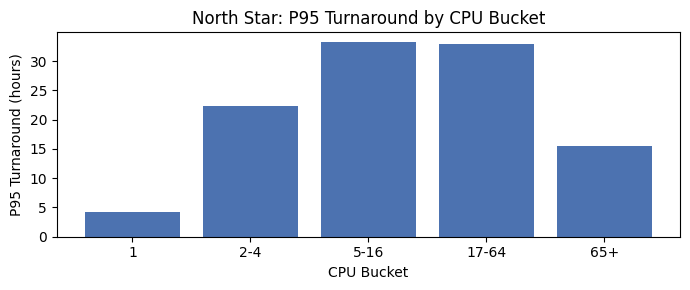

In [8]:
#  North Star: P95 turnaround by CPU bucket ───

ns_by_cpu = (
    job_ns
    .groupby("cpu_bucket", observed=True)["turnaround_s"]
    .agg(
        jobs="count",
        p50=lambda x: x.quantile(0.50),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99)
    )
    .reset_index()
)

print("=== P95 Turnaround by CPU Bucket (seconds) ===")
display(ns_by_cpu)

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(ns_by_cpu["cpu_bucket"].astype(str), ns_by_cpu["p95"] / 3600, color="#4C72B0")
ax.set_xlabel("CPU Bucket")
ax.set_ylabel("P95 Turnaround (hours)")
ax.set_title("North Star: P95 Turnaround by CPU Bucket")
plt.tight_layout()
plt.show()

=== Failure Rate by Partition ===


,partition,jobs,failure_rate
0,"gpu,normal",19603,1.000
1,test,5,0.800
2,gpu,141339,0.703
3,normal,115748,0.475
4,gaia,10374,0.404


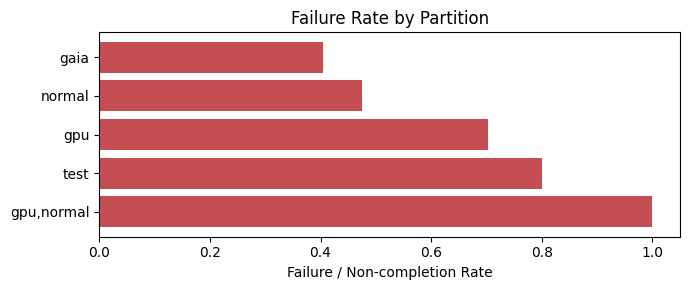

In [9]:
# Failure Rate by partition

fail_by_partition = (
    job_fail
    .groupby("partition")["is_not_completed"]
    .agg(["count", "mean"])
    .rename(columns={"count": "jobs", "mean": "failure_rate"})
    .sort_values("failure_rate", ascending=False)
    .reset_index()
)

print("=== Failure Rate by Partition ===")
display(fail_by_partition)

fig, ax = plt.subplots(figsize=(7, 3))
colors = ["#C44E52" if v > 0.3 else "#DD8452" if v > 0.1 else "#55A868"
          for v in fail_by_partition["failure_rate"]]
ax.barh(fail_by_partition["partition"], fail_by_partition["failure_rate"], color=colors)
ax.set_xlabel("Failure / Non-completion Rate")
ax.set_title("Failure Rate by Partition")
plt.tight_layout()
plt.show()

=== GPU SM Utilization by Partition (GPU-observed jobs only) ===


,partition,gpu_jobs,p25,median,p75
1,normal,74118,0.000,15.000,48.000
0,gaia,716,0.000,0.000,82.094
2,test,4,0.000,0.000,0.000


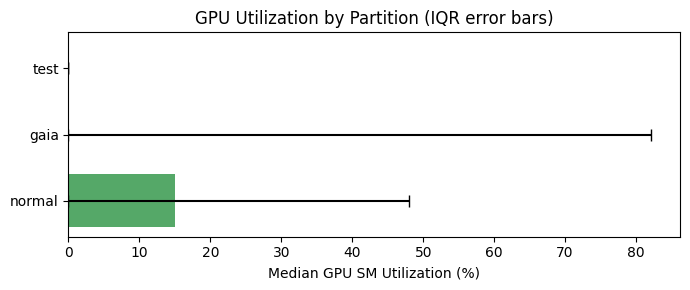

In [10]:
# GPU Utilization by partition (GPU-observed jobs only) 
util_col = "sm_util_mean"

gpu_by_part = (
    gpu_jobs
    .groupby("partition")[util_col]
    .agg(
        gpu_jobs="count",
        p25=lambda x: x.quantile(0.25),
        median="median",
        p75=lambda x: x.quantile(0.75)
    )
    .reset_index()
    .sort_values("median", ascending=False)
)

print("=== GPU SM Utilization by Partition (GPU-observed jobs only) ===")
display(gpu_by_part)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(gpu_by_part["partition"], gpu_by_part["median"], xerr=[
    gpu_by_part["median"] - gpu_by_part["p25"],
    gpu_by_part["p75"]    - gpu_by_part["median"]
], color="#55A868", capsize=4)
ax.set_xlabel("Median GPU SM Utilization (%)")
ax.set_title("GPU Utilization by Partition (IQR error bars)")
plt.tight_layout()
plt.show()

#### Conclusion

The global P95 turnaround masks a 6× performance gap across partitions and an 8× gap across CPU buckets, meaning workload mix shifts alone can move the headline number with no actual change in per-segment performance. The failure rate situation is structurally alarming — even the best-performing partition (gaia) has a 40.4% non-completion rate, and the gpu partition fails 70.3% of submitted jobs. GPU utilization shows a bimodal pattern in the normal partition (median 15%, IQR 0–48%), confirming that average utilization figures conceal a small number of intensive jobs alongside a majority running at near-zero.

### 3. Stability



**Why this step matters**

A metric is stable if its week-to-week variation is small enough to detect real operational
changes. High intrinsic noise makes it impossible to distinguish signal from random
fluctuation. We measure stability using:

- **Rolling mean and standard deviation** — tracks local variation over time
- **Coefficient of Variation (CV)** — normalised volatility, comparable across metrics
  with different scales. Defined as `std / mean` across all weeks.

A CV below ~0.3 is generally considered acceptable for operational metrics.
A CV above ~0.5 suggests the metric is too noisy for reliable weekly monitoring.

Global CV (P95 Turnaround): 0.677


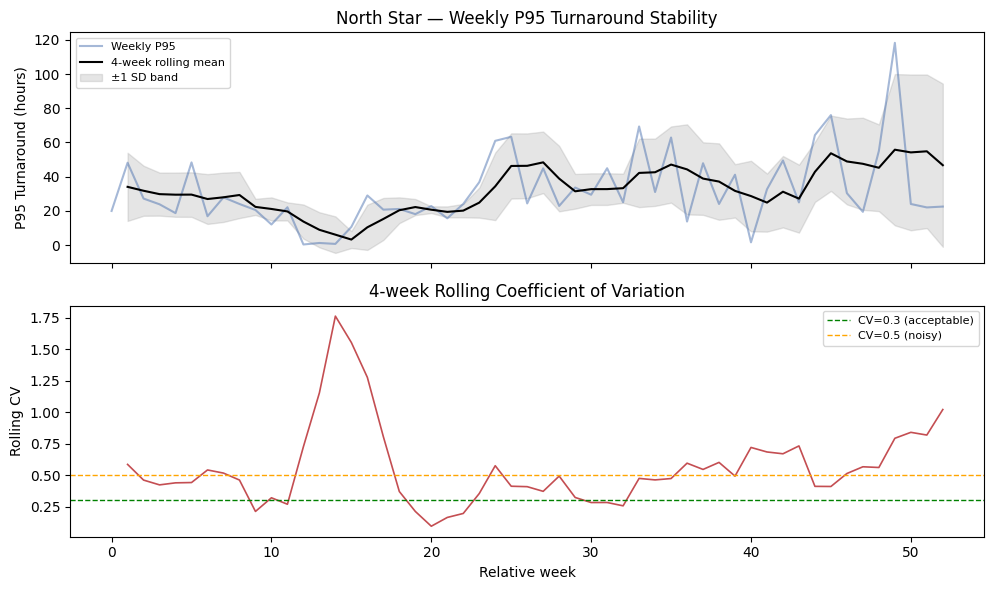

In [11]:
# Stability of the North Star (P95 Turnaround) 

ns = weekly_ns.set_index("t_rel_week").sort_index()

roll_mean = ns["p95_turnaround_s"].rolling(4, min_periods=2).mean()
roll_std  = ns["p95_turnaround_s"].rolling(4, min_periods=2).std()
roll_cv   = roll_std / roll_mean

cv_global = ns["p95_turnaround_s"].std() / ns["p95_turnaround_s"].mean()
print(f"Global CV (P95 Turnaround): {cv_global:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(ns.index, ns["p95_turnaround_s"] / 3600, alpha=0.5, label="Weekly P95", color="#4C72B0")
axes[0].plot(ns.index, roll_mean / 3600, color="black", linewidth=1.5, label="4-week rolling mean")
axes[0].fill_between(ns.index,
                     (roll_mean - roll_std) / 3600,
                     (roll_mean + roll_std) / 3600,
                     alpha=0.2, color="grey", label="±1 SD band")
axes[0].set_ylabel("P95 Turnaround (hours)")
axes[0].set_title("North Star — Weekly P95 Turnaround Stability")
axes[0].legend(fontsize=8)

axes[1].plot(ns.index, roll_cv, color="#C44E52", linewidth=1.2)
axes[1].axhline(0.3, color="green",  linestyle="--", linewidth=1, label="CV=0.3 (acceptable)")
axes[1].axhline(0.5, color="orange", linestyle="--", linewidth=1, label="CV=0.5 (noisy)")
axes[1].set_ylabel("Rolling CV")
axes[1].set_xlabel("Relative week")
axes[1].set_title("4-week Rolling Coefficient of Variation")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Global CV (Failure Rate): 0.234


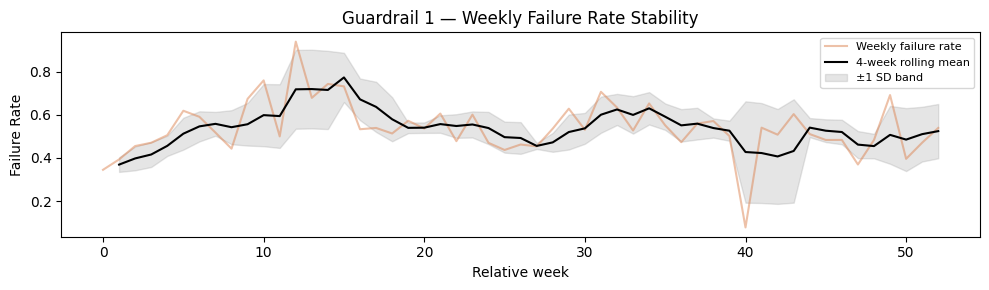

In [12]:
#  Stability of Failure Rate 

fail = weekly_fail.set_index("t_rel_week").sort_index()

roll_mean_f = fail["failure_rate"].rolling(4, min_periods=2).mean()
roll_std_f  = fail["failure_rate"].rolling(4, min_periods=2).std()

cv_fail = fail["failure_rate"].std() / fail["failure_rate"].mean()
print(f"Global CV (Failure Rate): {cv_fail:.3f}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(fail.index, fail["failure_rate"], alpha=0.5, label="Weekly failure rate", color="#DD8452")
ax.plot(fail.index, roll_mean_f, color="black", linewidth=1.5, label="4-week rolling mean")
ax.fill_between(fail.index,
                roll_mean_f - roll_std_f,
                roll_mean_f + roll_std_f,
                alpha=0.2, color="grey", label="±1 SD band")
ax.set_ylabel("Failure Rate")
ax.set_xlabel("Relative week")
ax.set_title("Guardrail 1 — Weekly Failure Rate Stability")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Global CV (Median GPU Utilization): 1.162


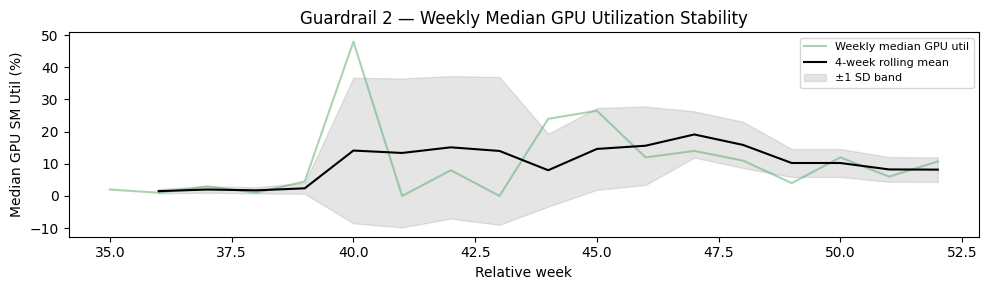


=== Stability Summary ===


,Metric,Global CV,Assessment
0,P95 Turnaround,0.677,Noisy
1,Failure Rate,0.234,Stable
2,GPU Utilization,1.162,Noisy


In [13]:
# Stability of GPU Utilization 

gpu_w = weekly_gpu.set_index("t_rel_week").sort_index()

roll_mean_g = gpu_w["median_gpu_util"].rolling(4, min_periods=2).mean()
roll_std_g  = gpu_w["median_gpu_util"].rolling(4, min_periods=2).std()

cv_gpu = gpu_w["median_gpu_util"].std() / gpu_w["median_gpu_util"].mean()
print(f"Global CV (Median GPU Utilization): {cv_gpu:.3f}")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(gpu_w.index, gpu_w["median_gpu_util"], alpha=0.5, label="Weekly median GPU util", color="#55A868")
ax.plot(gpu_w.index, roll_mean_g, color="black", linewidth=1.5, label="4-week rolling mean")
ax.fill_between(gpu_w.index,
                roll_mean_g - roll_std_g,
                roll_mean_g + roll_std_g,
                alpha=0.2, color="grey", label="±1 SD band")
ax.set_ylabel("Median GPU SM Util (%)")
ax.set_xlabel("Relative week")
ax.set_title("Guardrail 2 — Weekly Median GPU Utilization Stability")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Summary table
stability_summary = pd.DataFrame({
    "Metric"    : ["P95 Turnaround", "Failure Rate", "GPU Utilization"],
    "Global CV" : [cv_global, cv_fail, cv_gpu],
    "Assessment": [
        "Noisy" if cv_global > 0.5 else "Moderate" if cv_global > 0.3 else "Stable",
        "Noisy" if cv_fail   > 0.5 else "Moderate" if cv_fail   > 0.3 else "Stable",
        "Noisy" if cv_gpu    > 0.5 else "Moderate" if cv_gpu    > 0.3 else "Stable",
    ]
})
print("\n=== Stability Summary ===")
display(stability_summary)

#### Interpretation

The Failure Rate is the only metric suitable for week-to-week monitoring, with a CV of 0.23. The North Star (CV 0.677) and GPU Utilization (CV 1.162) are both too noisy for reliable weekly comparisons — large swings should always be cross-checked against job volume before being interpreted as operational signals. The high CV in the North Star is structurally expected given the extreme heavy tails identified in EDA, not a sign of a poorly chosen metric.

### 4. Drift


Drift refers to a systematic, directional change in a metric over time — distinct from
random week-to-week noise measured in the stability section. A metric that drifts
significantly suggests that the underlying system behavior has changed, which has
implications for baseline comparisons and historical benchmarks.

**Method:**  
We split the 53-week timeline into two halves (early and late period) and compare
the distribution of each metric across the two periods using:
- Descriptive statistics (median, P95)
- **Mann-Whitney U test** — a non-parametric test comparing the rank-order distribution
  of two independent samples, appropriate for heavy-tailed data

In [14]:
# Define early vs late split

midpoint = weekly_ns["t_rel_week"].median()
print(f"Split point (median week): {midpoint}")

def period_label(w): return "early" if w <= midpoint else "late"

weekly_ns["period"]   = weekly_ns["t_rel_week"].apply(period_label)
weekly_fail["period"] = weekly_fail["t_rel_week"].apply(period_label)
weekly_gpu["period"]  = weekly_gpu["t_rel_week"].apply(period_label)

#  North Star drift 

early_ns = weekly_ns.loc[weekly_ns["period"] == "early",  "p95_turnaround_s"]
late_ns  = weekly_ns.loc[weekly_ns["period"] == "late",   "p95_turnaround_s"]

u_stat_ns, p_ns = stats.mannwhitneyu(early_ns.dropna(), late_ns.dropna(), alternative="two-sided")

ns_drift = pd.DataFrame({
    "Period": ["Early", "Late"],
    "Weeks" : [len(early_ns), len(late_ns)],
    "Median P95 (s)"  : [early_ns.median(), late_ns.median()],
    "P95 of weekly P95 (s)": [early_ns.quantile(0.95), late_ns.quantile(0.95)]
})

print("=== North Star Drift ===")
display(ns_drift)
print(f"Mann-Whitney U = {u_stat_ns:.1f},  p = {p_ns:.4f}")

Split point (median week): 26.0
=== North Star Drift ===


,Period,Weeks,Median P95 (s),P95 of weekly P95 (s)
0,Early,27,"79,490.800","205,788.630"
1,Late,26,"114,431.450","267,652.075"


Mann-Whitney U = 185.0,  p = 0.0032


In [15]:
#  Failure Rate drift 

early_f = weekly_fail.loc[weekly_fail["period"] == "early", "failure_rate"]
late_f  = weekly_fail.loc[weekly_fail["period"] == "late",  "failure_rate"]

u_stat_f, p_f = stats.mannwhitneyu(early_f.dropna(), late_f.dropna(), alternative="two-sided")

fail_drift = pd.DataFrame({
    "Period": ["Early", "Late"],
    "Median Failure Rate": [early_f.median(), late_f.median()],
    "Max Failure Rate"   : [early_f.max(),    late_f.max()]
})

print("=== Failure Rate Drift ===")
display(fail_drift)
print(f"Mann-Whitney U = {u_stat_f:.1f},  p = {p_f:.4f}")

=== Failure Rate Drift ===


,Period,Median Failure Rate,Max Failure Rate
0,Early,0.533,0.940
1,Late,0.529,0.707


Mann-Whitney U = 372.0,  p = 0.7153


In [16]:
#  GPU Utilization drift 

early_g = weekly_gpu.loc[weekly_gpu["t_rel_week"] <= midpoint, "median_gpu_util"]
late_g  = weekly_gpu.loc[weekly_gpu["t_rel_week"] >  midpoint, "median_gpu_util"]

u_stat_g, p_g = stats.mannwhitneyu(early_g.dropna(), late_g.dropna(), alternative="two-sided")

gpu_drift = pd.DataFrame({
    "Period": ["Early", "Late"],
    "Median GPU Util (%)": [early_g.median(), late_g.median()],
    "P75 GPU Util (%)"   : [early_g.quantile(0.75), late_g.quantile(0.75)]
})

print("=== GPU Utilization Drift ===")
display(gpu_drift)
print(f"Mann-Whitney U = {u_stat_g:.1f},  p = {p_g:.4f}")

# ── Summary ───────────────────────────────────────────────────────────────
drift_summary = pd.DataFrame({
    "Metric"      : ["P95 Turnaround", "Failure Rate", "GPU Utilization"],
    "Mann-Whitney p": [p_ns, p_f, p_g],
    "Drift detected (p<0.05)": [p_ns < 0.05, p_f < 0.05, p_g < 0.05]
})
print("\n=== Drift Summary ===")
display(drift_summary)

=== GPU Utilization Drift ===


/var/folders/w2/s7f15lxs51zcy_sqpvy8rm480000gn/T/ipykernel_14999/3310021293.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u_stat_g, p_g = stats.mannwhitneyu(early_g.dropna(), late_g.dropna(), alternative="two-sided")


,Period,Median GPU Util (%),P75 GPU Util (%)
0,Early,NaN,NaN
1,Late,7.000,12.000


Mann-Whitney U = nan,  p = nan

=== Drift Summary ===


,Metric,Mann-Whitney p,Drift detected (p<0.05)
0,P95 Turnaround,0.003,True
1,Failure Rate,0.715,False
2,GPU Utilization,NaN,False


/var/folders/w2/s7f15lxs51zcy_sqpvy8rm480000gn/T/ipykernel_14999/1751854921.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Early", "Late"], patch_artist=True,
/var/folders/w2/s7f15lxs51zcy_sqpvy8rm480000gn/T/ipykernel_14999/1751854921.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Early", "Late"], patch_artist=True,
/var/folders/w2/s7f15lxs51zcy_sqpvy8rm480000gn/T/ipykernel_14999/1751854921.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Early", "Late"], patch_artist=True,


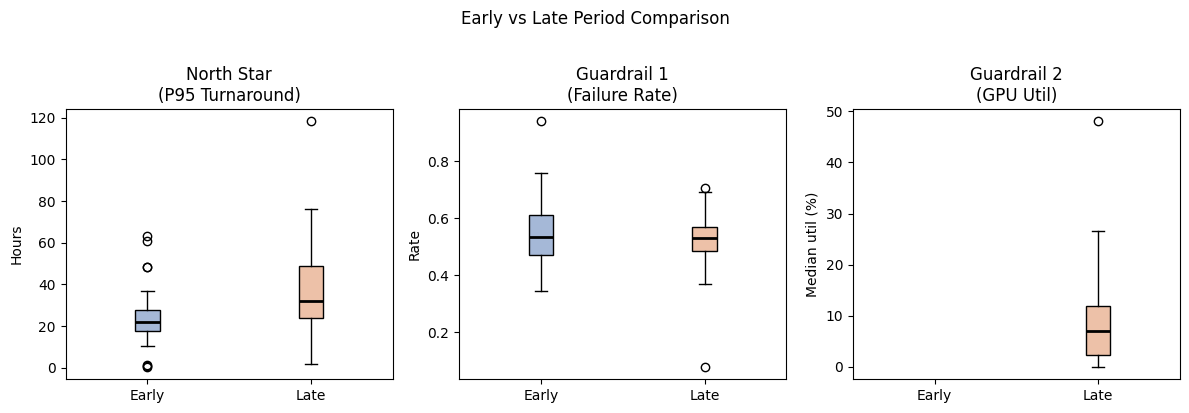

In [17]:
#  Visual: early vs late box plots for all three metrics 

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

def boxplot_periods(ax, early, late, title, ylabel, scale=1.0):
    data = [early.dropna() / scale, late.dropna() / scale]
    bp = ax.boxplot(data, labels=["Early", "Late"], patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#4C72B080")
    bp["boxes"][1].set_facecolor("#DD845280")
    ax.set_title(title)
    ax.set_ylabel(ylabel)

boxplot_periods(axes[0], early_ns, late_ns, "North Star\n(P95 Turnaround)", "Hours", scale=3600)
boxplot_periods(axes[1], early_f,  late_f,  "Guardrail 1\n(Failure Rate)",  "Rate")
boxplot_periods(axes[2], early_g,  late_g,  "Guardrail 2\n(GPU Util)",       "Median util (%)")

plt.suptitle("Early vs Late Period Comparison", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

#### Interpretation

The North Star has drifted significantly across the year — median weekly P95 increased by ~9.7 hours from the first half to the second half (Mann-Whitney p=0.003), which means a full-year baseline is not appropriate for benchmarking current performance. The Failure Rate shows no significant drift (p=0.715), making it a stable reference point for year-over-year comparisons. GPU Utilization cannot be assessed for drift because telemetry only exists in the second half of the year.

### 5. Reliability


A weekly metric estimate is computed from a finite sample of jobs. Even if the underlying
system is perfectly stable, the estimated value will vary due to sampling noise. For a
tail metric like P95, this noise can be substantial in weeks with few jobs.

**Method:**  
We use **bootstrap resampling** to estimate the 95% confidence interval around each
week's P95 turnaround estimate. For each week:
1. Sample with replacement from the week's jobs (B=1000 iterations)
2. Compute P95 on each bootstrap sample
3. Report the 2.5th and 97.5th percentiles as the CI bounds

A wide CI relative to the point estimate indicates that the week's P95 should be
interpreted with caution.

In [18]:
# Bootstrap CI for weekly P95 turnaround 

BOOTSTRAP_ITERS = 1000
np.random.seed(42)

def bootstrap_p95_ci(values, B=BOOTSTRAP_ITERS, alpha=0.05):
    """Return (point_estimate, lower_ci, upper_ci) for P95 via bootstrap."""
    arr   = np.asarray(values)
    point = np.percentile(arr, 95)
    boots = np.empty(B)
    for i in range(B):
        sample = np.random.choice(arr, size=len(arr), replace=True)
        boots[i] = np.percentile(sample, 95)
    lower = np.percentile(boots, 100 * alpha / 2)
    upper = np.percentile(boots, 100 * (1 - alpha / 2))
    return point, lower, upper

results = []
for week, grp in job_ns.groupby("t_rel_week"):
    n = len(grp)
    pt, lo, hi = bootstrap_p95_ci(grp["turnaround_s"].values)
    results.append({"t_rel_week": week, "n_jobs": n,
                    "p95_point": pt, "ci_lower": lo, "ci_upper": hi,
                    "ci_width" : hi - lo, "ci_rel_width": (hi - lo) / pt})

boot_df = pd.DataFrame(results).sort_values("t_rel_week").reset_index(drop=True)

print("=== Bootstrap CI Summary (P95 Turnaround) ===")
display(boot_df[["t_rel_week","n_jobs","p95_point","ci_lower","ci_upper","ci_rel_width"]].head(10))

=== Bootstrap CI Summary (P95 Turnaround) ===


,t_rel_week,n_jobs,p95_point,ci_lower,ci_upper,ci_rel_width
0,0,962,"71,723.850","65,328.942","84,043.300",0.261
1,1,801,"173,279.000","126,221.000","178,645.000",0.303
2,2,589,"97,838.000","86,414.535","100,928.000",0.148
3,3,304,"85,750.450","59,921.550","89,815.757",0.349
4,4,539,"67,150.000","43,403.410","86,564.890",0.643
5,5,315,"173,956.900","105,806.000","182,278.000",0.440
6,6,448,"60,583.150","43,227.300","86,403.000",0.713
7,7,552,"100,338.650","86,410.900","120,429.400",0.339
8,8,477,"86,427.400","82,727.790","99,970.200",0.200
9,9,902,"73,760.350","61,820.950","86,406.900",0.333


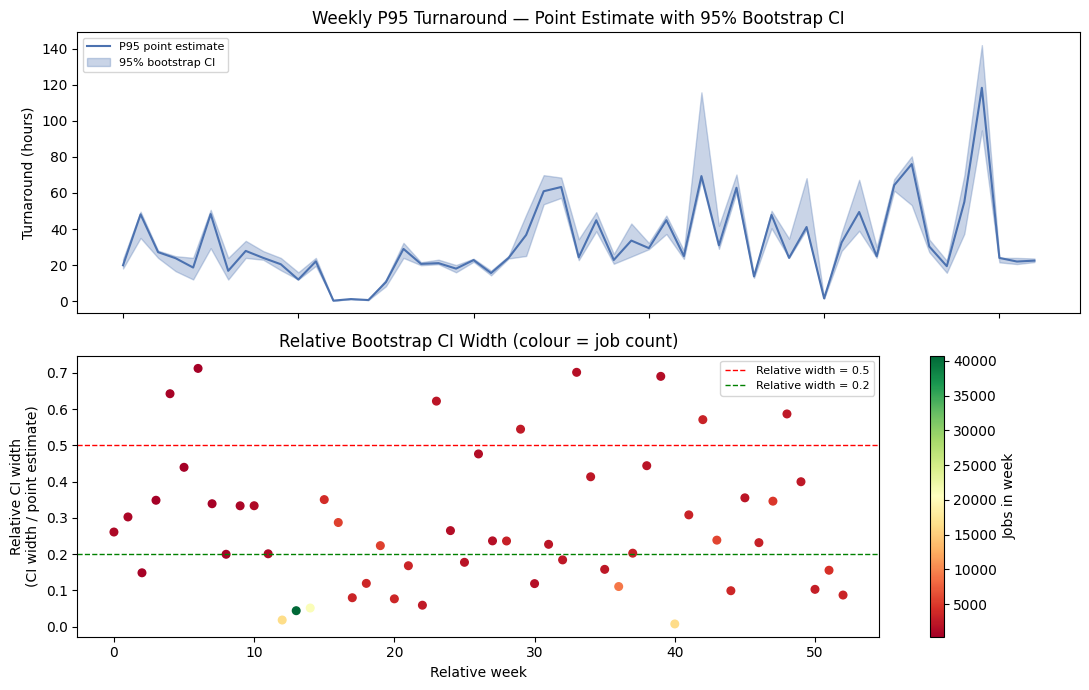

In [19]:
#  Plot: P95 estimates with 95% bootstrap CI 

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Top: P95 with CI ribbon
axes[0].plot(boot_df["t_rel_week"], boot_df["p95_point"] / 3600,
             color="#4C72B0", linewidth=1.5, label="P95 point estimate")
axes[0].fill_between(boot_df["t_rel_week"],
                     boot_df["ci_lower"] / 3600,
                     boot_df["ci_upper"] / 3600,
                     alpha=0.3, color="#4C72B0", label="95% bootstrap CI")
axes[0].set_ylabel("Turnaround (hours)")
axes[0].set_title("Weekly P95 Turnaround — Point Estimate with 95% Bootstrap CI")
axes[0].legend(fontsize=8)

# Bottom: Relative CI width coloured by job count
sc = axes[1].scatter(boot_df["t_rel_week"], boot_df["ci_rel_width"],
                     c=boot_df["n_jobs"], cmap="RdYlGn", s=30)
axes[1].axhline(0.5, color="red",    linestyle="--", linewidth=1, label="Relative width = 0.5")
axes[1].axhline(0.2, color="green",  linestyle="--", linewidth=1, label="Relative width = 0.2")
axes[1].set_ylabel("Relative CI width\n(CI width / point estimate)")
axes[1].set_xlabel("Relative week")
axes[1].set_title("Relative Bootstrap CI Width (colour = job count)")
axes[1].legend(fontsize=8)
plt.colorbar(sc, ax=axes[1], label="Jobs in week")

plt.tight_layout()
plt.show()

In [20]:
# Reliability by sample size 

# Bin weeks by job count to show how reliability varies with sample size
boot_df["size_bin"] = pd.cut(boot_df["n_jobs"], bins=[0, 500, 2000, 5000, 1e8],
                              labels=["< 500", "500-2k", "2k-5k", "> 5k"])

rel_by_size = (
    boot_df.groupby("size_bin", observed=True)["ci_rel_width"]
    .agg(["count", "mean", "median"])
    .rename(columns={"count": "weeks", "mean": "mean_rel_width", "median": "median_rel_width"})
    .reset_index()
)

print("=== Reliability by Weekly Job Count ===")
display(rel_by_size)

=== Reliability by Weekly Job Count ===


,size_bin,weeks,mean_rel_width,median_rel_width
0,< 500,4,0.425,0.394
1,500-2k,15,0.366,0.333
2,2k-5k,26,0.264,0.215
3,> 5k,8,0.122,0.081


#### Conclusion. 

On a typical week the 95% bootstrap CI spans ±12% around the P95 point estimate, which is acceptable. However, 8 weeks have a relative CI width above 0.5 and 4 weeks fall below the 500-job reliability threshold — these weeks should carry a warning label in any dashboard rather than displaying a precise point estimate. The best and worst week CI widths (0.01 vs 0.71) illustrate how dramatically reliability degrades in thin weeks.

### 6. Sensitivity



**Why this step matters**

A good operational metric should react to genuine changes in system pressure —
otherwise it cannot serve as an early warning signal. A metric that does not move
when workload increases or the system is under stress has low **discriminative power**
and is unlikely to be actionable.

**Method:**  
We test whether the North Star metric responds to changes in two workload pressure
proxies that can be computed from the scheduler data:
- **Weekly job volume** — total number of jobs submitted
- **Weekly CPU demand** — total CPUs requested across all jobs

We report the Spearman rank correlation between each proxy and the weekly P95
turnaround time. Spearman correlation is used because both variables are skewed.

In [21]:
# Workload pressure proxies from job-level data 

weekly_pressure = (
    job_ns
    .groupby("t_rel_week")
    .agg(
        job_volume=("id_job", "count"),
        total_cpus=("cpus_req", "sum")
    )
    .reset_index()
)

# Merge with weekly North Star
sens_df = weekly_ns.merge(weekly_pressure, on="t_rel_week")

# Spearman correlations
rho_vol, p_vol   = stats.spearmanr(sens_df["job_volume"], sens_df["p95_turnaround_s"])
rho_cpu, p_cpu   = stats.spearmanr(sens_df["total_cpus"], sens_df["p95_turnaround_s"])

sens_summary = pd.DataFrame({
    "Pressure proxy"  : ["Weekly job volume", "Weekly CPU demand"],
    "Spearman rho"    : [rho_vol, rho_cpu],
    "p-value"         : [p_vol,   p_cpu],
    "Significant (p<0.05)": [p_vol < 0.05, p_cpu < 0.05]
})

print("=== Sensitivity: Spearman Rank Correlation with P95 Turnaround ===")
display(sens_summary)

=== Sensitivity: Spearman Rank Correlation with P95 Turnaround ===


,Pressure proxy,Spearman rho,p-value,Significant (p<0.05)
0,Weekly job volume,-0.337,0.014,True
1,Weekly CPU demand,0.012,0.934,False


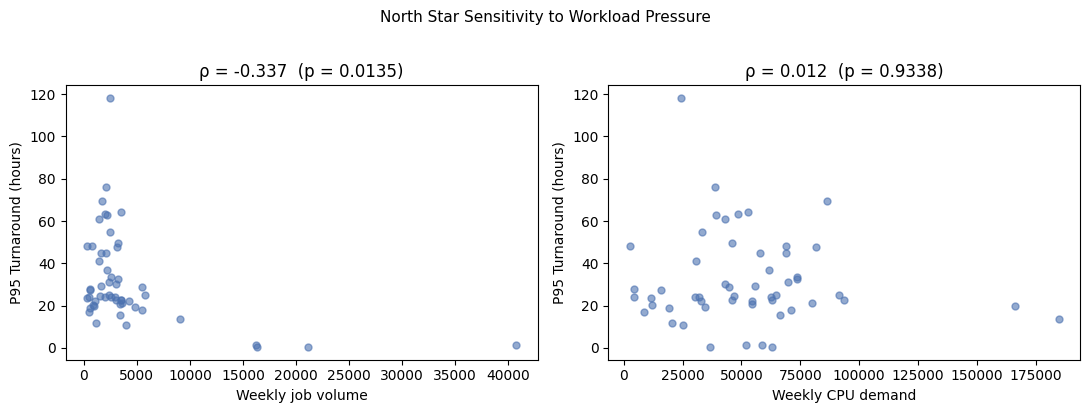

In [22]:
# Scatter plots: pressure vs P95 

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, label, rho, p in [
    (axes[0], "job_volume", "Weekly job volume",  rho_vol, p_vol),
    (axes[1], "total_cpus", "Weekly CPU demand",  rho_cpu, p_cpu),
]:
    ax.scatter(sens_df[col], sens_df["p95_turnaround_s"] / 3600,
               alpha=0.6, s=25, color="#4C72B0")
    ax.set_xlabel(label)
    ax.set_ylabel("P95 Turnaround (hours)")
    ax.set_title(f"ρ = {rho:.3f}  (p = {p:.4f})")

plt.suptitle("North Star Sensitivity to Workload Pressure", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
#  High-pressure weeks: do they show higher P95? 

# Define high-pressure weeks as top quartile by job volume
q75_vol = sens_df["job_volume"].quantile(0.75)
sens_df["high_pressure"] = sens_df["job_volume"] >= q75_vol

high = sens_df.loc[sens_df["high_pressure"],  "p95_turnaround_s"]
low  = sens_df.loc[~sens_df["high_pressure"], "p95_turnaround_s"]

u_stat, p_sens = stats.mannwhitneyu(high, low, alternative="greater")

pressure_tbl = pd.DataFrame({
    "Pressure level" : ["High (top 25% job volume)", "Low / moderate"],
    "Weeks"          : [len(high), len(low)],
    "Median P95 (s)" : [high.median(), low.median()],
    "Mean P95 (s)"   : [high.mean(),   low.mean()]
})

print("=== High vs Low Pressure Weeks ===")
display(pressure_tbl)
print(f"Mann-Whitney U = {u_stat:.1f},  p (one-tailed, high > low) = {p_sens:.4f}")

=== High vs Low Pressure Weeks ===


,Pressure level,Weeks,Median P95 (s),Mean P95 (s)
0,High (top 25% job volume),14,"67,458.925","64,184.657"
1,Low / moderate,39,"105,930.700","132,927.599"


Mann-Whitney U = 102.0,  p (one-tailed, high > low) = 0.9997


#### Interpretation

The North Star shows a moderate negative correlation with job volume (ρ = −0.337, p = 0.014), meaning P95 tends to be lower in busier weeks — a counterintuitive but real finding that likely reflects workload composition rather than improved performance under load. CPU demand shows no significant relationship with P95 (ρ = 0.012, p = 0.934), and the high-pressure vs low-pressure week comparison is also non-significant (p = 0.9997), suggesting the metric is driven more by individual outlier jobs than by aggregate congestion. The North Star has limited use as a congestion early-warning signal in its current form.

### 7. CUPED — Controlled-experiment Using Pre-Experiment Data



**Why this step matters**

CUPED is a variance-reduction technique originally developed for A/B testing
(Deng et al., 2013). The key insight is that if a pre-period observation of the
same metric is available and correlated with the current-period value, it can be
used as a covariate to remove predictable noise.

In an A/B testing context, CUPED reduces the required sample size for a given
statistical power. In an observational monitoring context, it demonstrates the
potential for a more stable metric by removing variation that is explained by
a prior period's value.

**Formula:**

$$Y_{\text{CUPED}} = Y - \theta \cdot (X - \mathbb{E}[X])$$

Where:
- $Y$ = current-week metric value  
- $X$ = previous-week metric value (pre-experiment covariate)  
- $\theta = \text{Cov}(Y, X) / \text{Var}(X)$ (OLS regression coefficient)  
- $\mathbb{E}[X]$ = mean of the covariate

The CUPED-adjusted value has the **same mean** as the original but lower variance
when $X$ and $Y$ are positively correlated.

In [25]:
#  Prepare week-over-week pairs

def prepare_cuped_pairs(weekly_df, metric_col, min_weeks=4):
    """
    Create a DataFrame of (X = previous week, Y = current week) pairs for CUPED.
    Requires at least `min_weeks` observations to be meaningful.
    """
    df = weekly_df[["t_rel_week", metric_col]].dropna().sort_values("t_rel_week").copy()
    df["X"] = df[metric_col].shift(1)     # previous week value
    df["Y"] = df[metric_col]              # current week value
    df = df.dropna(subset=["X", "Y"])
    print(f"CUPED pairs: {len(df)}")
    return df

ns_pairs   = prepare_cuped_pairs(weekly_ns,   "p95_turnaround_s")
fail_pairs = prepare_cuped_pairs(weekly_fail, "failure_rate")
gpu_pairs  = prepare_cuped_pairs(weekly_gpu,  "median_gpu_util")

CUPED pairs: 52
CUPED pairs: 52
CUPED pairs: 17


In [26]:
# CUPED adjustment function 

def apply_cuped(pairs_df, y_col="Y", x_col="X"):
    """
    Apply CUPED adjustment to a DataFrame of (X, Y) week pairs.
    Returns the DataFrame with Y_cuped column added and variance comparison.
    """
    Y = pairs_df[y_col].values
    X = pairs_df[x_col].values

    theta = np.cov(Y, X)[0, 1] / np.var(X)
    X_mean = X.mean()

    pairs_df = pairs_df.copy()
    pairs_df["Y_cuped"] = Y - theta * (X - X_mean)

    var_original = np.var(Y, ddof=1)
    var_cuped    = np.var(pairs_df["Y_cuped"], ddof=1)
    var_reduction = 1 - var_cuped / var_original

    print(f"  theta = {theta:.4f}")
    print(f"  Original variance : {var_original:.4f}")
    print(f"  CUPED variance    : {var_cuped:.4f}")
    print(f"  Variance reduction: {var_reduction:.1%}")
    return pairs_df, theta, var_reduction

print("=== CUPED: North Star (P95 Turnaround) ===")
ns_cuped,   theta_ns,   vr_ns   = apply_cuped(ns_pairs,   y_col="Y", x_col="X")

print("\n=== CUPED: Failure Rate ===")
fail_cuped, theta_fail, vr_fail = apply_cuped(fail_pairs, y_col="Y", x_col="X")

print("\n=== CUPED: GPU Utilization ===")
gpu_cuped,  theta_gpu,  vr_gpu  = apply_cuped(gpu_pairs,  y_col="Y", x_col="X")

=== CUPED: North Star (P95 Turnaround) ===
  theta = 0.1973
  Original variance : 6126230084.5047
  CUPED variance    : 5896325108.6790
  Variance reduction: 3.8%

=== CUPED: Failure Rate ===
  theta = 0.2453
  Original variance : 0.0155
  CUPED variance    : 0.0146
  Variance reduction: 6.1%

=== CUPED: GPU Utilization ===
  theta = -0.0856
  Original variance : 151.2794
  CUPED variance    : 150.2717
  Variance reduction: 0.7%


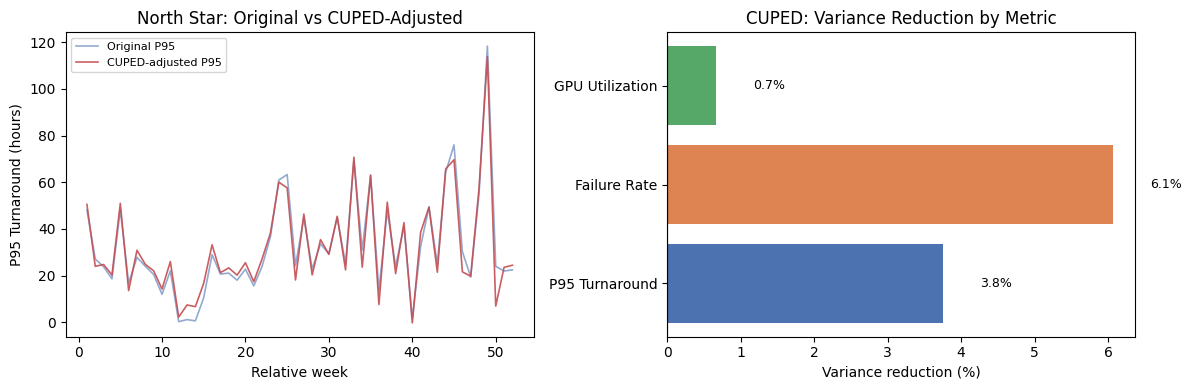

In [27]:
# Visualise CUPED effect for the North Star 

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: original vs CUPED time series
ax = axes[0]
ax.plot(ns_cuped["t_rel_week"], ns_cuped["Y"]       / 3600,
        alpha=0.6, label="Original P95", color="#4C72B0", linewidth=1.2)
ax.plot(ns_cuped["t_rel_week"], ns_cuped["Y_cuped"] / 3600,
        alpha=0.9, label="CUPED-adjusted P95", color="#C44E52", linewidth=1.2)
ax.set_xlabel("Relative week")
ax.set_ylabel("P95 Turnaround (hours)")
ax.set_title("North Star: Original vs CUPED-Adjusted")
ax.legend(fontsize=8)

# Right: variance comparison bar chart for all three metrics
ax2 = axes[1]
metrics   = ["P95 Turnaround", "Failure Rate", "GPU Utilization"]
var_reds  = [vr_ns, vr_fail, vr_gpu]
colors    = ["#4C72B0", "#DD8452", "#55A868"]
bars = ax2.barh(metrics, [v * 100 for v in var_reds], color=colors)
ax2.set_xlabel("Variance reduction (%)")
ax2.set_title("CUPED: Variance Reduction by Metric")
ax2.axvline(0, color="black", linewidth=0.8)
for bar, v in zip(bars, var_reds):
    ax2.text(max(v * 100 + 0.5, 1), bar.get_y() + bar.get_height() / 2,
             f"{v:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [28]:
#  Correlation between X and Y (prerequisite check) 

for label, df in [("North Star", ns_cuped), ("Failure Rate", fail_cuped), ("GPU Util", gpu_cuped)]:
    rho, p = stats.spearmanr(df["X"], df["Y"])
    print(f"{label:15s}  Spearman rho(X, Y) = {rho:.3f}   p = {p:.4f}   ",
          "CUPED useful" if rho > 0.3 and p < 0.05 else "Weak covariate")

North Star       Spearman rho(X, Y) = 0.251   p = 0.0728    Weak covariate
Failure Rate     Spearman rho(X, Y) = 0.300   p = 0.0308    Weak covariate
GPU Util         Spearman rho(X, Y) = 0.070   p = 0.7892    Weak covariate


#### Interpretation


All three metrics show weak week-to-week autocorrelation, with covariate correlations of ρ = 0.25, 0.30, and 0.07 for the North Star, Failure Rate, and GPU Utilization respectively. As a result, CUPED delivers negligible variance reduction — 3.8%, 6.1%, and 0.7% — making it impractical for this dataset in its current weekly aggregation. The underlying reason is that extreme weeks in a heavy-tailed system are largely unpredictable from the prior week, which is precisely the condition under which CUPED loses its benefit.

## Overall Conclusion

This validation exercise set out to answer a single question: are the three selected
operational metrics trustworthy enough to guide decisions about the HPC cluster?
The answer is nuanced and differs substantially across the three metrics.

---

### Failure Rate — Most Reliable Metric

The Failure Rate is the most reliable metric of the three. It has complete population
coverage, stable week-to-week behavior (CV = 0.23), no significant drift across the year
(Mann-Whitney p = 0.715), and no dependency on sparse telemetry. It can be used as a
consistent operational baseline and is the one metric where a full-year aggregate is
statistically defensible.

Its critical limitation is not statistical but operational: failure rates are structurally
high across every partition, with the `gpu` partition failing **70.3%** of submitted jobs
and even the best-performing partition (`gaia`) failing **40.4%**. This makes the Failure
Rate less useful as a routine monitoring signal and more of a standing indictment of system
reliability that warrants independent investigation.

---

### North Star (P95 Turnaround) — Valid in Concept, Requires Careful Handling

The choice of P95 over mean is well-justified by the extreme heavy-tailed distributions
confirmed in EDA, and the metric does show meaningful sensitivity to job volume
(Spearman ρ = −0.337, p = 0.014). However, it fails several validity checks that limit
how confidently it can be acted upon:

- **Stability:** Too noisy for reliable week-to-week comparisons (CV = 0.677)
- **Drift:** Median P95 increased by ~9.7 hours in the second half of the year
  (Mann-Whitney p = 0.003) — a full-year baseline is not appropriate
- **Reliability:** 8 weeks produce bootstrap CIs too wide to treat point estimates as
  precise readings; 4 weeks fall below the 500-job reliability threshold
- **Segmentation:** A 6× gap across partitions and an 8× gap across CPU buckets mean
  the global metric is heavily composition-dependent — a workload mix shift can move
  the headline number with no change in actual per-segment performance

The metric is not wrong, but it should **never be reported without segment-level
breakdowns**, and historical benchmarks should use a recent rolling window rather than
a full-year average given the detected drift.

---

### GPU Utilization — Not Fit for Purpose as a Weekly Metric

The GPU Utilization guardrail, as currently constructed, is not fit for purpose as a
weekly operational metric:

- Only **18 of 53 weeks** have sufficient data to compute it
- Telemetry is **entirely absent** from the dedicated `gpu` partition (0% coverage)
- The metric only covers `normal`-partition jobs — not the intended target population
- CV = 1.162 makes week-to-week comparisons meaningless
- Drift cannot be assessed due to the data gap in the first half of the year

The low median SM utilization of **15%** with a wide IQR of 0–48% is a genuinely
important efficiency finding, but it should be reported as a **point-in-time audit result**
for the second half of the year, not as an ongoing weekly guardrail. If GPU efficiency
monitoring is a genuine business priority, resolving the telemetry gap in the `gpu`
partition is a prerequisite before this metric can serve its intended governance role.

---

### Broader Methodological Finding — CUPED and Experimentation

CUPED delivered negligible variance reduction across all three metrics (3.8%, 6.1%, and
0.7%), because week-to-week autocorrelation is too low in a heavy-tailed, spike-driven
system for prior-period values to reliably predict current-period values.

This means that if this cluster were used to run scheduling experiments, standard A/B
testing would require large sample sizes and long observation windows. Any future
experimentation framework would need to account for this — likely by moving to
**job-level randomization** rather than weekly aggregates, or by identifying a stronger
pre-experiment covariate than the prior week's metric value.

---

### Summary

| Metric | Verdict | Key Condition |
|--------|---------|---------------|
| Failure Rate | ✅ Use as-is | Report alongside P95; investigate structural causes |
| P95 Turnaround | ⚠️ Use with conditions | Always segment by partition and CPU bucket; use rolling baseline |
| GPU Utilization | ❌ Suspend as weekly guardrail | Resolve `gpu` partition telemetry gap first |

> **In short:** report the Failure Rate as a stable system-health indicator, report the
> North Star only with segment breakdowns and reliability flags, suspend the GPU
> utilization guardrail until the telemetry gap is resolved, and treat any week-to-week
> movement in the North Star with skepticism unless it is large, sustained, and consistent
> across segments.